In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from IPython.display import display

from tqdm import tqdm

import pandas as pd

import scipy

from scipy import stats

from scipy.ndimage import gaussian_filter

import pyunfold as pu

from scipy.io import loadmat
from scipy.interpolate import interp1d

import dynesty

In [2]:
axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '12' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
ndim = 2

In [4]:
l_avg = np.array([0, 2])
l_std = np.array([
    [2,0],
    [1,1]
]).T
l_cov = l_std @ l_std.T
l_cov_inv = np.linalg.inv(l_cov)
l_det = - np.log(np.linalg.det(2*np.pi*l_cov))/2
def loglike(x):
    return -(x-l_avg) @ l_cov_inv @ (x-l_avg)/2 + l_det

p_avg = np.array([0, 0])
p_std = np.array([
    [1,0],
    [0,2]
]).T
def ptform(u):
    return p_avg + p_std @ scipy.stats.norm.ppf(u)

In [5]:
l_eig, l_vec = np.linalg.eig(l_cov)

In [6]:
p_cov = p_std @ p_std.T
p_eig, p_vec = np.linalg.eig(p_cov)

-6.245155600327012


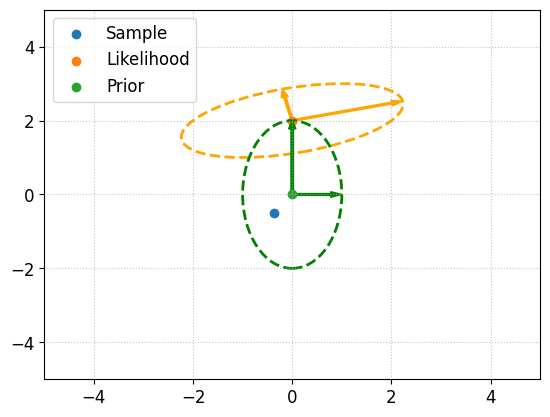

In [7]:
from matplotlib.patches import Ellipse

u = np.random.random(ndim)
x = ptform(u)
print(loglike(x))

fig, ax = plt.subplots(1,1)

plt.scatter(*x, label='Sample')

plt.arrow(*l_avg, *(l_vec[:,0]*np.sqrt(l_eig[0])), width=0.05, length_includes_head=True, fc='orange', color='orange')
plt.arrow(*l_avg, *(l_vec[:,1]*np.sqrt(l_eig[1])), width=0.05, length_includes_head=True, fc='orange', color='orange')
ellipse = Ellipse(xy=l_avg, width=np.sqrt(l_eig[0])*2, height=np.sqrt(l_eig[1])*2, angle=np.arccos(l_vec[0,0])*180/np.pi, ec='orange', fc='None', lw=2, ls='--')
ax.add_patch(ellipse)
plt.scatter(*l_avg, label='Likelihood')

plt.arrow(*p_avg, *(p_vec[:,0]*np.sqrt(p_eig[0])), width=0.05, length_includes_head=True, fc='g', color='g')
plt.arrow(*p_avg, *(p_vec[:,1]*np.sqrt(p_eig[1])), width=0.05, length_includes_head=True, fc='g', color='g')
ellipse = Ellipse(xy=p_avg, width=np.sqrt(p_eig[0])*2, height=np.sqrt(p_eig[1])*2, angle=np.arccos(p_vec[0,0])*180/np.pi, ec='g', fc='None', lw=2, ls='--')
ax.add_patch(ellipse)
plt.scatter(*p_avg, label='Prior')

plt.xlim(-5,5)
plt.ylim(-5,5)
plt.legend()
plt.show()

In [8]:
sampler = dynesty.NestedSampler(loglike, ptform, ndim)

In [9]:
sampler.run_nested()
sresults = sampler.results

1156it [00:01, 1152.02it/s, +500 | bound: 0 | nc: 1 | ncall: 5872 | eff(%): 30.827 | loglstar:   -inf < -2.531 <    inf | logz: -3.956 +/-    nan | dlogz:  0.001 >  0.509]


In [10]:
sresults.logz[-1]

np.float64(-3.9564680466921898)

In [11]:
sresults.logzerr[-1]

np.float64(0.08779444778885077)

In [12]:
t_cov = p_std @ p_std.T + l_cov
logz_true = -(p_avg-l_avg) @ np.linalg.inv(t_cov) @ (p_avg-l_avg)/2 - np.log(np.linalg.det(2*np.pi*t_cov))/2
logz_true

np.float64(-3.9353180848508584)

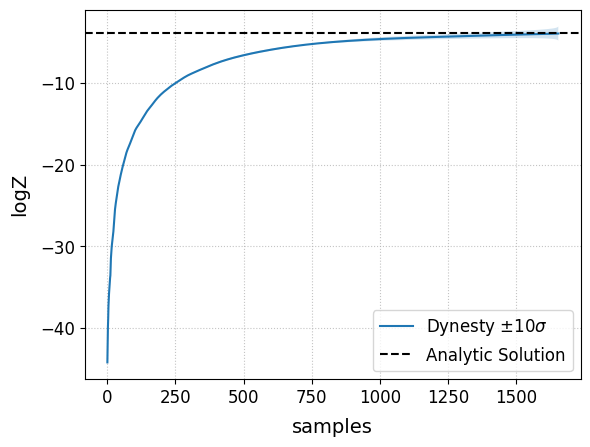

In [23]:
plt.fill_between(np.arange(len(sresults.logz)), sresults.logz-sresults.logzerr*10, sresults.logz+sresults.logzerr*10, alpha=0.2)
plt.plot(sresults.logz, label=r'Dynesty $\pm 10\sigma$')
plt.axhline(logz_true, c='k', ls='--', label='Analytic Solution')
plt.ylabel('logZ')
plt.xlabel('samples')
#plt.ylim(-6,-2)
plt.legend()

Text(0.5, 0, 'samples')

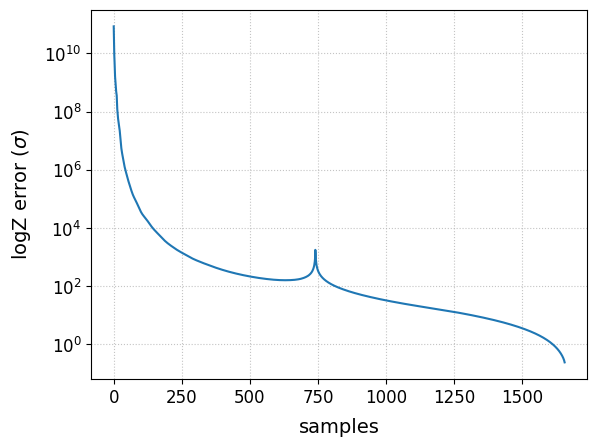

In [24]:
plt.plot(abs((logz_true-sresults.logz)/sresults.logzerr))
plt.yscale('log')
plt.ylabel(r'logZ error $(\sigma)$')
plt.xlabel('samples')

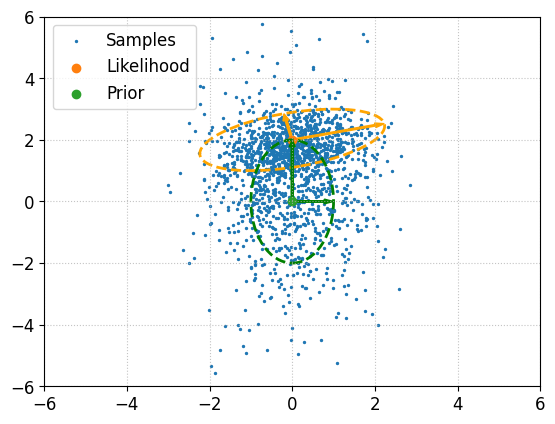

In [17]:
fig, ax = plt.subplots(1,1)

i = 0
plt.scatter(*sresults.samples.T[:,i:], s=2, label='Samples')
#ax.contourf(*sresults.samples.T, sresults.logl)

plt.arrow(*l_avg, *(l_vec[:,0]*np.sqrt(l_eig[0])), width=0.05, length_includes_head=True, fc='orange', color='orange')
plt.arrow(*l_avg, *(l_vec[:,1]*np.sqrt(l_eig[1])), width=0.05, length_includes_head=True, fc='orange', color='orange')
ellipse = Ellipse(xy=l_avg, width=np.sqrt(l_eig[0])*2, height=np.sqrt(l_eig[1])*2, angle=np.arccos(l_vec[0,0])*180/np.pi, ec='orange', fc='None', lw=2, ls='--')
ax.add_patch(ellipse)
plt.scatter(*l_avg, label='Likelihood')

plt.arrow(*p_avg, *(p_vec[:,0]*np.sqrt(p_eig[0])), width=0.05, length_includes_head=True, fc='g', color='g')
plt.arrow(*p_avg, *(p_vec[:,1]*np.sqrt(p_eig[1])), width=0.05, length_includes_head=True, fc='g', color='g')
ellipse = Ellipse(xy=p_avg, width=np.sqrt(p_eig[0])*2, height=np.sqrt(p_eig[1])*2, angle=np.arccos(p_vec[0,0])*180/np.pi, ec='g', fc='None', lw=2, ls='--')
ax.add_patch(ellipse)
plt.scatter(*p_avg, label='Prior')

plt.xlim(-6,6)
plt.ylim(-6,6)
plt.legend()
plt.show()

In [16]:
sresults

          nlive: 500
          niter: 1156
          ncall: array([1, 1, 1, ..., 1, 1, 1])
            eff: 30.8265078183172
        samples: array([[ 1.07746092, -5.22949777],
       [-1.8682857 , -5.57482692],
       [-1.97318111, -5.35574507],
       ...,
       [ 0.08326261,  2.0000854 ],
       [-0.03541224,  1.96092474],
       [-0.01254565,  1.9932559 ]])
           blob: array([None, None, None, ..., None, None, None], dtype=object)
 proposal_stats: array([{'n_proposals': 1}, {'n_proposals': 1}, {'n_proposals': 1}, ...,
       None, None, None], dtype=object)
     samples_id: array([365,  49, 492, ..., 107, 382, 420])
     samples_it: array([   0,    0,    0, ...,    0,  230, 1037])
      samples_u: array([[0.8593628 , 0.00446465],
       [0.03086113, 0.00265653],
       [0.02423747, 0.00370457],
       ...,
       [0.53317863, 0.84135508],
       [0.48587551, 0.83657103],
       [0.49499514, 0.84052743]])
          logwt: array([-44.1992919 , -42.0752987 , -40.0025529 , ..., -